In [6]:
#Importing Libraries
import os
import numpy as np
import cv2
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Rescaling, GlobalAveragePooling2D, Input, RandomFlip, RandomRotation, RandomZoom
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [7]:
#Fetch image count from folders
count = 0
dirs = os.listdir('Images/')

for dir in dirs:
    parent_path = os.path.join('Images', dir)
    if os.path.isdir(parent_path):
        subdirs = os.listdir(parent_path)
        for subdir in subdirs:
            sub_path = os.path.join(parent_path, subdir)
            if os.path.isdir(sub_path):
                files = [f for f in os.listdir(sub_path) if not f.startswith('.')]
                print(f"{dir}/{subdir} folder has {len(files)} images")
                count += len(files)

print('Total images:', count)


test/infected folder has 781 images
test/notinfected folder has 1141 images
train/infected folder has 781 images
train/notinfected folder has 1143 images
Total images: 3846


In [8]:
#parameters to improve generalisation
base_dir = 'Images/train'
img_size = 180
batch = 32 #images processed together

In [9]:
#load images into arrays as dataset
train_ds = tf.keras.utils.image_dataset_from_directory(base_dir,
                                                       seed = 123,
                                                       validation_split=0.2, #80% training, 20% validation
                                                       subset = 'training',
                                                       color_mode='grayscale',
                                                       batch_size=batch,
                                                       image_size=(img_size,img_size)) #resizes images
class_names = train_ds.class_names 


val_ds = tf.keras.utils.image_dataset_from_directory(base_dir,
                                                     seed = 123,
                                                       validation_split=0.2,
                                                       subset = 'validation',
                                                     color_mode='grayscale',
                                                       batch_size=batch,
                                                       image_size=(img_size,img_size))

Found 1924 files belonging to 2 classes.
Using 1540 files for training.
Found 1924 files belonging to 2 classes.
Using 384 files for validation.


In [10]:
folder_names = train_ds.class_names
folder_names

['infected', 'notinfected']

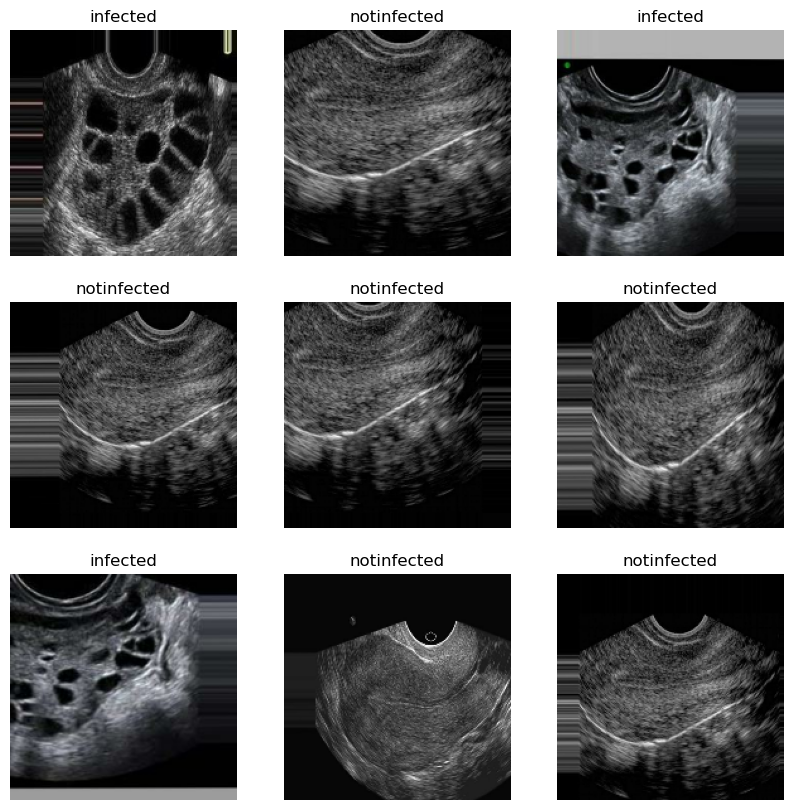

In [55]:
#Samples from dataset
plt.figure(figsize=(10,10)) #blank matplotlib figure to hold images

for images, labels in train_ds.take(1): #takes 1 batch of batched datset
    for i in range(9): #first 9 images
        plt.subplot(3,3, i+1) #creates subplot
        plt.imshow(images[i].numpy().astype('uint8')) #image is converted into numpy array  and displayed correctly 
        plt.title(folder_names[labels[i]]) #class name is added as title
        plt.axis('off') #hides axis 

In [11]:
#optimises
AUTOTUNE = tf.data.AUTOTUNE 
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size = AUTOTUNE)

In [14]:
#Data Augumentation for generalisation
augmentation = Sequential([
    Input(shape=(img_size, img_size, 1)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

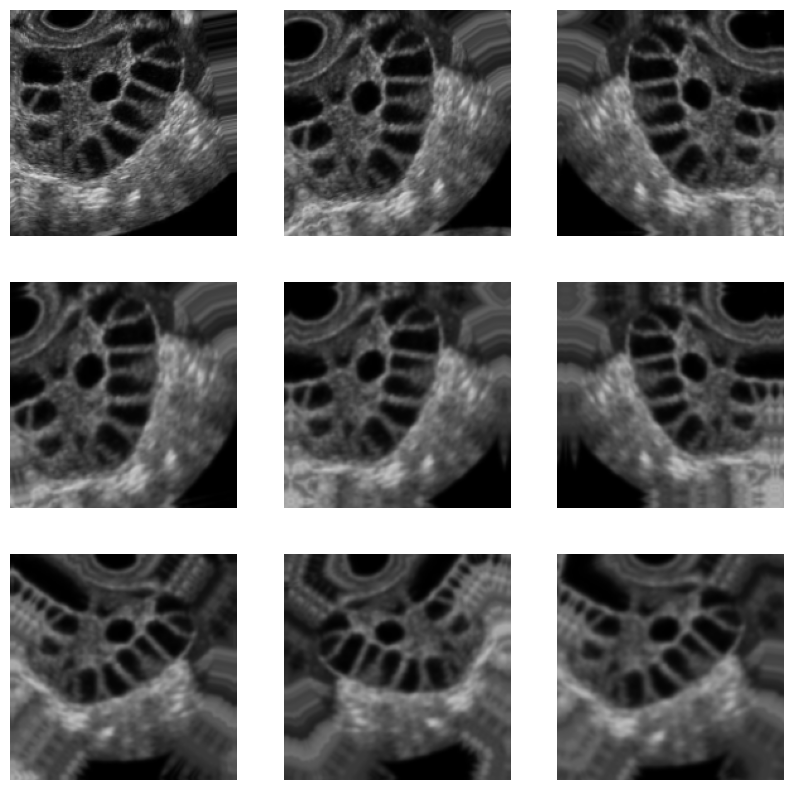

In [59]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        images = data_augmentation(images)
        plt.subplot(3,3, i+1)
        plt.imshow(images[0].numpy().astype('uint8'))
        plt.axis('off')

In [15]:
#Model creation
model = Sequential([ #layers applied one after another
    augmentation,#random transformations applied
    layers.Rescaling(1./255), #normalise pixel values
    
    Conv2D(16, 3, padding='same', activation='relu'),  #extract important features
    MaxPooling2D(), #reduce image dimensions but keeps features
    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    
    Conv2D(64, 3, padding='same', activation='relu'), #deeper features
    MaxPooling2D(),
    Dropout(0.2), #prevents overfitting by adding noise
    
    GlobalAveragePooling2D(), #will reduct spatial info and feed into dense layers
    Dense(64, activation='relu'),
    Dense(2, activation='softmax')]) 

In [16]:
model.compile(optimizer='adam', #adapts learning rates for each parameter
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), #tells model how wrong predictions are and guide it
              metrics=['accuracy'])

In [26]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 180, 180, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 180, 180, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 180, 180, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,586 (107.76 KB)

 Trainable params: 27,586 (107.76 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
#fit model with datatsets
history = model.fit(train_ds, epochs=15, validation_data=val_ds)

Epoch 1/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 17s 308ms/step - accuracy: 0.5849 - loss: 0.6846 - val_accuracy: 0.5807 - val_loss: 0.6297
Epoch 2/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 15s 314ms/step - accuracy: 0.6921 - loss: 0.5557 - val_accuracy: 0.5651 - val_loss: 0.7598
Epoch 3/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 17s 340ms/step - accuracy: 0.8454 - loss: 0.3399 - val_accuracy: 0.6615 - val_loss: 0.6350
Epoch 4/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 16s 337ms/step - accuracy: 0.8659 - loss: 0.2892 - val_accuracy: 0.5729 - val_loss: 1.0981
Epoch 5/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 14s 295ms/step - accuracy: 0.9270 - loss: 0.2030 - val_accuracy: 0.5781 - val_loss: 1.1958
Epoch 6/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 15s 314ms/step - accuracy: 0.9186 - loss: 0.1934 - val_accuracy: 0.5104 - val_loss: 1.6588
Epoch 7/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 16s 329ms/step - accuracy: 0.9320 - loss: 0.1678 - val_accuracy: 0.6250 - val_loss: 1.0853
Epoch 8/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 15s 313ms/step - accuracy: 0.9503 - loss: 0.1389 - val_accu

In [18]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    'Images/test',
    image_size=(180, 180),
    color_mode='grayscale',  # since your ultrasound images are grayscale
    batch_size=32,           # or whatever you used for training
    shuffle=False            # don't shuffle — useful for matching predictions to images
)

Found 1922 files belonging to 2 classes.


In [19]:
model.evaluate(test_ds)

61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - accuracy: 0.9273 - loss: 0.1438


[0.3308410048484802, 0.8319458961486816]

In [25]:
def classify_images(image_path):
    img = tf.keras.utils.load_img(image_path, target_size=(180, 180), color_mode='grayscale')
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Shape: (1, 180, 180, 1)

    predictions = model.predict(img_array)
    predicted_class = tf.argmax(predictions[0]).numpy()
    confidence = tf.reduce_max(tf.nn.softmax(predictions[0])).numpy()

    class_names = test_ds.class_names  # ['Infected', 'Not Infected']
    print(f"Predicted class: {class_names[predicted_class]} (Confidence: {confidence:.2f})")

    return predicted_class


In [22]:
classify_images('Sample/infected.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted class: infected (Confidence: 0.73)


0

In [24]:
#class counts
class_names = train_ds.class_names

# Count labels
label_counts = [0] * len(class_names)
for _, labels in train_ds:
    for label in labels.numpy():
        label_counts[label] += 1

# Plot
sns.barplot(x=class_names, y=label_counts)
plt.title("Class Distribution in Training Set")
plt.ylabel("Number of Images")
plt.show()

AttributeError: '_PrefetchDataset' object has no attribute 'class_names'

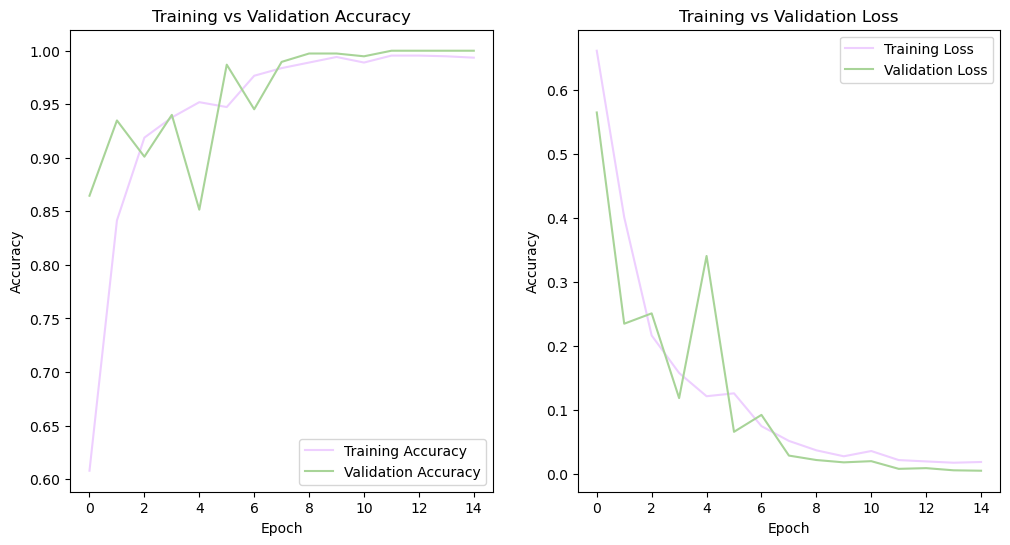

In [71]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(15)

plt.figure(figsize=(12, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.plot(epochs_range, acc, label='Training Accuracy', color="#eecfff")
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color="#a8d498")
plt.legend(loc='lower right')
plt.title('Training vs Validation Accuracy')

# Loss Plot
plt.subplot(1, 2, 2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.plot(epochs_range, loss, label='Training Loss', color="#eecfff")
plt.plot(epochs_range, val_loss, label='Validation Loss', color="#a8d498")
plt.legend(loc='upper right')
plt.title('Training vs Validation Loss')

plt.show()


In [62]:
#true labels
y_true = []
for _, labels in test_ds:
    y_true.extend(labels.numpy())

#Predict classes
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Step 3: Generate the report
print(classification_report(y_true, y_pred, target_names=['Infected', 'Not Infected']))


61/61 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step
              precision    recall  f1-score   support

    Infected       1.00      1.00      1.00       781
Not Infected       1.00      1.00      1.00      1141

    accuracy                           1.00      1922
   macro avg       1.00      1.00      1.00      1922
weighted avg       1.00      1.00      1.00      1922



In [23]:
# Get class names
class_names = train_ds.class_names

# Count labels in training set
train_counts = [0] * len(class_names)
for _, labels in train_ds:
    for label in labels.numpy():
        train_counts[label] += 1

# Count labels in test set
test_counts = [0] * len(class_names)
for _, labels in test_ds:
    for label in labels.numpy():
        test_counts[label] += 1

# Create bar chart
x = range(len(class_names))
bar_width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x, train_counts, width=bar_width, color="#f7c9c9", label="Training Set")
plt.bar([i + bar_width for i in x], test_counts, width=bar_width, color="#a3185e", label="Test Set")

# Formatting
plt.xticks([i + bar_width / 2 for i in x], class_names)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution in Training vs Test Set")
plt.legend()
plt.tight_layout()
plt.show()

AttributeError: '_PrefetchDataset' object has no attribute 'class_names'

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━

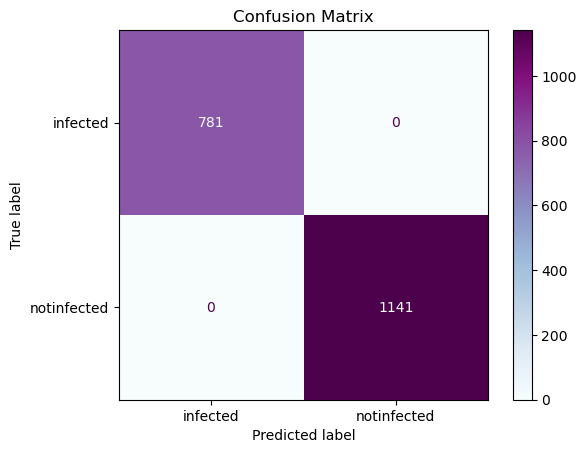

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#  true and predicted labels from the val set
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)
    y_pred.extend(preds)
    y_true.extend(labels.numpy())

#Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

#display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=folder_names)
disp.plot(cmap=plt.cm.BuPu)
plt.title("Confusion Matrix")
plt.show()


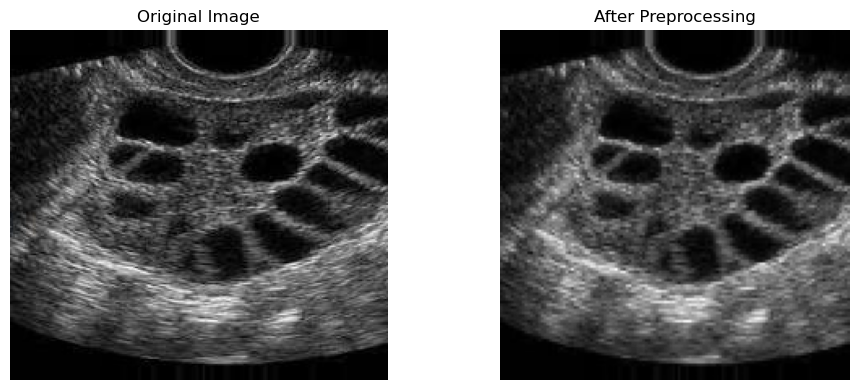

In [97]:
# Load one sample image (update the path if needed)
img_path = 'Images/test/infected/img_0_113.jpg'
original = cv2.imread(img_path)
gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
resized = cv2.resize(gray, (128, 128))
normalized = resized / 255.0

# Plot before and after preprocessing
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(original)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("After Preprocessing")
plt.imshow(normalized, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()